# 06 - Results summary (capstone)

Pulls together the primary comparison across all models on the binary
escalation target (EBM, XGBoost base+topo, XGBoost+forecast, CNN), resolves
the open peak-vs-cumulative-extent labeling question, and narrates the
project arc end to end. No new modeling here -- every number either comes
from a prior notebook's committed result or is derived fresh from the DB/HDF5
in Step 2 below.

Runs in the `flashpoint` kernel (x86_64) -- nothing here needs torch, only
`cnn_preds.csv` (exported from `flashpoint_mps` in notebook 05's Step 5).

## Step 0: load exported CNN predictions

See notebook 05 Step 5 for the export cell (`cnn_preds.to_csv("../data/cnn_preds.csv", index=False)`).

In [1]:
import sys
sys.path.insert(0, "../src")

## Step 1: confusion matrix comparison, all models

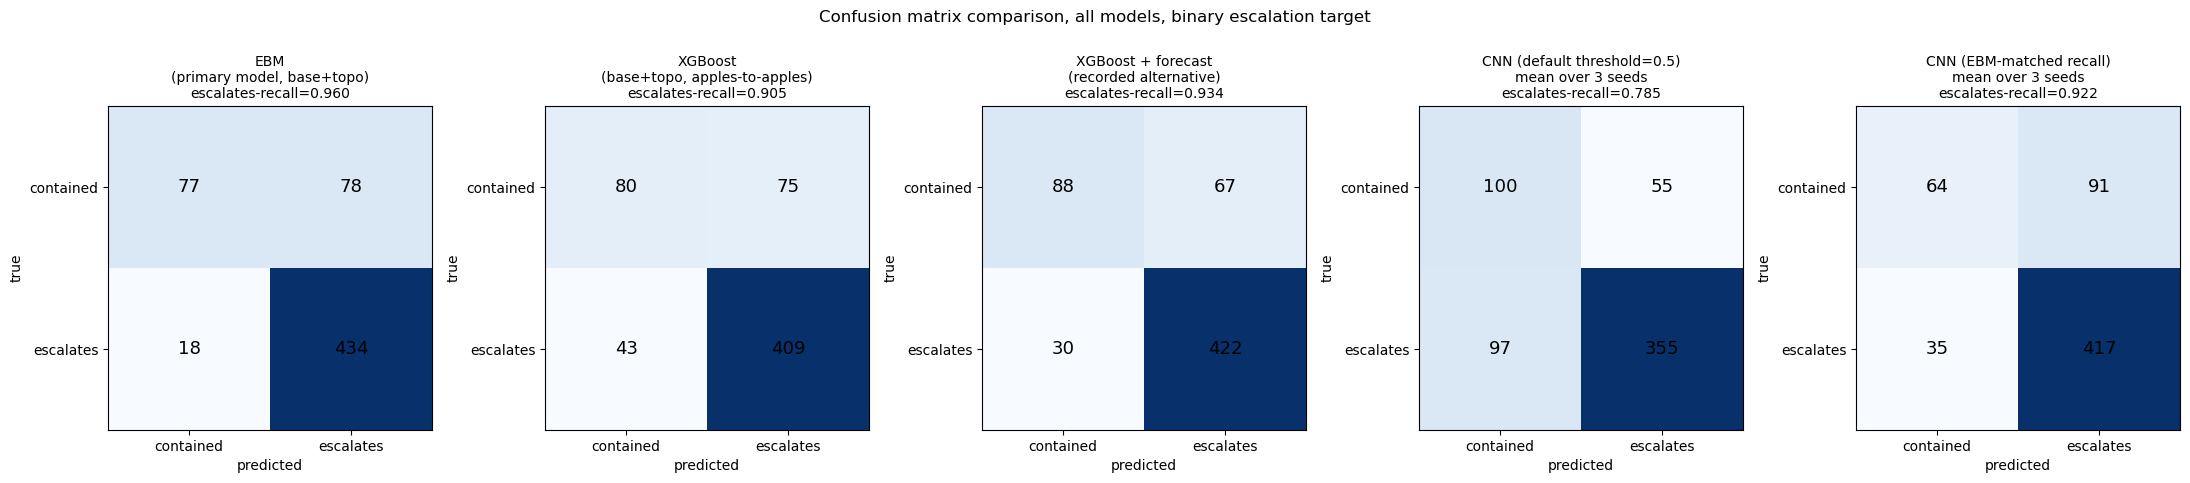

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EBM_CM = np.array([[77, 78], [18, 434]])
XGB_CM = np.array([[80, 75], [43, 409]])
XGB_FORECAST_CM = np.array([[88, 67], [30, 422]])
SEEDS = (0, 1, 2)
matched_thresholds = {0: 0.19, 1: 0.11, 2: 0.21}

cnn_preds = pd.read_csv("../data/cnn_preds.csv")

def confusion_from_preds(df, seed, threshold):
    sub = df[df["seed"] == seed]
    y_true = sub["y_true"].values
    y_prob = sub["p_escalate"].values
    y_pred = (y_prob >= threshold).astype(int)
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    return np.array([[tn, fp], [fn, tp]])

cnn_default_mean = np.mean([confusion_from_preds(cnn_preds, s, 0.5) for s in SEEDS], axis=0)
cnn_matched_mean = np.mean(
    [confusion_from_preds(cnn_preds, s, matched_thresholds[s]) for s in SEEDS], axis=0
)

panels = [
    ("EBM\n(primary model, base+topo)", EBM_CM),
    ("XGBoost\n(base+topo, apples-to-apples)", XGB_CM),
    ("XGBoost + forecast\n(recorded alternative)", XGB_FORECAST_CM),
    ("CNN (default threshold=0.5)\nmean over 3 seeds", cnn_default_mean),
    ("CNN (EBM-matched recall)\nmean over 3 seeds", cnn_matched_mean),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, (title, cm) in zip(axes, panels):
    recall = cm[1, 1] / (cm[1, 1] + cm[1, 0])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:.0f}", ha="center", va="center", fontsize=13)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["contained", "escalates"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["contained", "escalates"])
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{title}\nescalates-recall={recall:.3f}", fontsize=10)

plt.suptitle("Confusion matrix comparison, all models, binary escalation target")
plt.tight_layout()

## Step 2: peak extent vs. cumulative footprint

Open question carried since notebook 01: severity labels are derived from
**peak** single-day active-fire extent, not the union of fire pixels seen
across the whole trajectory. If a fire spreads and recedes over multiple
disjoint areas, cumulative footprint could tell a different severity story
than peak extent. Resolved here, fresh, against the full 607-event DB --
this notebook opens its own DuckDB connection (closed in the final cell).


  0%|          | 0/607 [00:00<?, ?it/s]


  2%|▏         | 13/607 [00:00<00:04, 127.47it/s]


  4%|▍         | 26/607 [00:00<00:04, 126.32it/s]


  7%|▋         | 40/607 [00:00<00:04, 128.91it/s]


  9%|▊         | 53/607 [00:00<00:04, 122.59it/s]

...


 97%|█████████▋| 588/607 [00:04<00:00, 115.62it/s]


 99%|█████████▉| 602/607 [00:04<00:00, 120.81it/s]


100%|██████████| 607/607 [00:04<00:00, 137.25it/s]

Pearson r = 0.850 (p=1.28e-170)
Spearman r = 0.949 (p=2.92e-305)


159/607 events (26.2%) would land in a different severity tier if labeled by cumulative footprint instead of peak extent


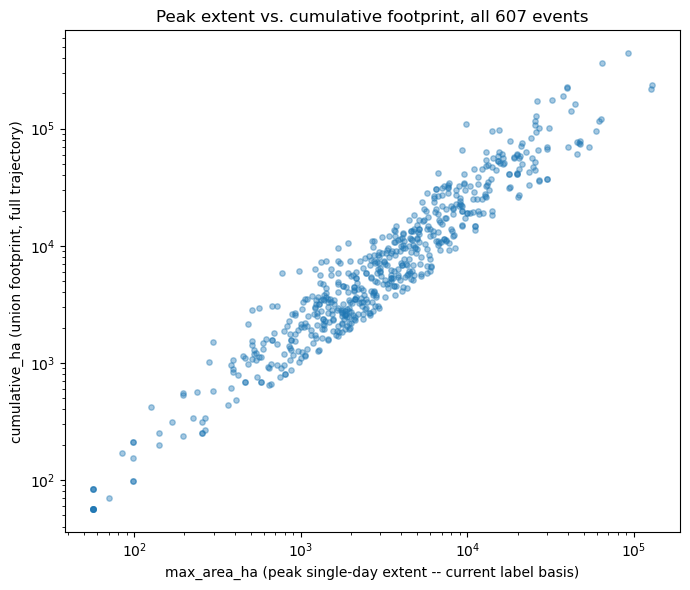

In [3]:
from pathlib import Path
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr
from flashpoint.db import get_connection
from flashpoint.data_access import HDF5Event, read_channel_all_days, ACTIVE_FIRE_CHANNEL_IDX, PIXEL_AREA_HA

DB_PATH = Path("../data/flashpoint.duckdb")
con = get_connection(DB_PATH)

events_df = con.execute("SELECT event_id, hdf5_path, n_days FROM events").df()
outcomes_df = con.execute("SELECT event_id, max_area_ha, severity_class FROM event_outcomes").df()

cumulative_ha = []
for _, row in tqdm(events_df.iterrows(), total=len(events_df)):
    event = HDF5Event(event_id=row['event_id'], year=0, hdf5_path=Path(row['hdf5_path']),
                       n_days=row['n_days'], img_dates=[], lnglat=(0, 0))
    af_all_days = read_channel_all_days(event, ACTIVE_FIRE_CHANNEL_IDX)
    union_mask = (af_all_days > 0).any(axis=0)
    cumulative_ha.append(float(union_mask.sum()) * PIXEL_AREA_HA)

events_df['cumulative_ha'] = cumulative_ha
merged = events_df.merge(outcomes_df, on='event_id')

r_pearson, p_pearson = pearsonr(merged['max_area_ha'], merged['cumulative_ha'])
r_spearman, p_spearman = spearmanr(merged['max_area_ha'], merged['cumulative_ha'])
print(f"Pearson r = {r_pearson:.3f} (p={p_pearson:.2e})")
print(f"Spearman r = {r_spearman:.3f} (p={p_spearman:.2e})")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(merged['max_area_ha'], merged['cumulative_ha'], alpha=0.4, s=15)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('max_area_ha (peak single-day extent -- current label basis)')
ax.set_ylabel('cumulative_ha (union footprint, full trajectory)')
ax.set_title('Peak extent vs. cumulative footprint, all 607 events')
plt.tight_layout()

# How many events would land in a different severity tier if labeled by
# cumulative footprint instead of peak extent?
cum_quartiles = merged['cumulative_ha'].quantile([0.25, 0.5, 0.75]).tolist()
def bin_it(x, edges):
    for i, e in enumerate(edges):
        if x <= e:
            return i
    return len(edges)
merged['severity_class_cumulative'] = merged['cumulative_ha'].apply(lambda x: bin_it(x, cum_quartiles))
n_flipped = (merged['severity_class'] != merged['severity_class_cumulative']).sum()
print(f"{n_flipped}/{len(merged)} events ({100*n_flipped/len(merged):.1f}%) would land in a "
      f"different severity tier if labeled by cumulative footprint instead of peak extent")

**Finding (reported plainly, not spun toward either answer):** Pearson r =
0.850, Spearman r = 0.949 (both p << 0.001) -- peak extent and cumulative
footprint are strongly, monotonically related across the 607 events, which
is unsurprising (a fire that peaks large has usually also burned a large
cumulative area) and does support treating peak extent as a reasonable,
non-arbitrary severity proxy rather than a disconnected or misleading one.

But the flip-rate is not low: 159/607 events (26.2%) land in a *different*
severity quartile when tiered by cumulative footprint instead of peak
extent. A strong overall correlation and a one-in-four tier-flip rate are
both true at once -- quartile-binning is inherently sensitive near bin
edges, so a high rank correlation doesn't guarantee stable tier assignment
for the substantial minority of events sitting close to a quartile
boundary. Read together, this is a real, now-quantified limitation, not a
clean vindication: peak extent is a defensible severity basis, not the
only one, and roughly a quarter of events would be classified into a
different tier under the equally defensible cumulative-footprint
alternative.

## Step 3: project narrative

**Goal.** Predict wildfire severity -- a tier derived from a fire's
eventual peak extent -- from only the first 1-2 days of an active fire,
using WildfireSpreadTS (607 US wildfire trajectories, 2018-2021, 23 raster
channels at 24hr resolution). The point is early-state triage: how quickly
and heavily to mobilize response, before the fire's outcome is known.

**Pipeline.** Database-first: DuckDB holds a manifest (`events`), severity
labels computed over the *full* trajectory (`event_outcomes`), and tabular
features computed *only* from the day-1/day-2 cutoff window
(`early_features`). That asymmetry -- labels may see the whole trajectory,
model inputs may never see past the cutoff -- is the project's core
integrity constraint. Pixel data stays in HDF5 and is read on demand rather
than loaded in bulk.

**The buffer-day bug.** Stored sequences open with 4 pre-ignition padding
days, so the fire's actual day 1 is index `BUFFER_DAYS` (4), not index 0.
An early version of the feature pipeline sliced `[0, cutoff)`, silently
measuring pre-ignition conditions instead of the fire's actual early window
-- a leakage-adjacent bug that cost about 5 percentage points across every
downstream result once fixed. Severity itself is derived from *peak*
active-fire extent across the trajectory, not the last stored day, because
56.5% of events are padded with buffer days that show zero fire on their
literal last day -- last-day extent would have been mostly noise.

**Model comparison.** The Explainable Boosting Machine (EBM) on
base+topography tabular features is the primary model: LOYO mean accuracy
0.826, macro-F1 0.754, escalates-recall 0.953, against a 0.73/0.42/1.00
majority-class baseline. XGBoost is competitive but weaker on the metric
that matters most under a missed-escalation-costs-more doctrine
(escalates-recall) -- adding forecast-channel features helps XGBoost across
the board (accuracy 0.788 -> 0.822, macro-F1 0.718 -> 0.765) and gives it
the best false-alarm profile of any tabular model, but its recall (0.911)
still falls short of the EBM's 0.953, so the EBM remains primary. The
4-class quartile-tier target is kept as a secondary result (XGBoost leads
there, 0.46 accuracy vs. 0.25 chance) since most of its error sits at
adjacent-tier boundaries rather than being separable model error.

**CNN and Grad-CAM.** A small CNN on early raster crops was trained LOYO
across 3 seeds as a raster-native comparator to the tabular EBM. At its
default decision threshold the CNN appeared to beat the EBM on false
alarms (43-63 FP vs. 78), but a threshold sweep matching the CNN's
escalates-recall to the EBM's 0.953 showed that apparent win was an
artifact of the CNN operating at lower recall (0.74-0.79 at default
threshold) -- at matched recall the CNN produces *more* false alarms
(89-122 vs. 78), not fewer. The two models sit on similar points of a
similar precision-recall tradeoff curve; the CNN is not a performance
upgrade over the tabular baseline. Grad-CAM statistics over all 607 events
showed the CNN's attention is at least physically sensible despite that:
CAM mass concentrates 3.6x more than chance near early fire pixels, and
correlates weakly-positively with slope and ERC (fire danger index) --
directionally consistent with the EBM's own top-3 term importances
(fire_extent, slope, erc), though this is a qualitative, different-units
comparison, not proof the two models learned the same thing.

**Peak vs. cumulative extent.** The label-integrity question of whether
peak single-day extent is the right severity basis, versus cumulative
footprint across the trajectory, is resolved in Step 2 above rather than
left open: peak extent correlates strongly with cumulative footprint
(Pearson r=0.850, Spearman r=0.949) but still produces a different
severity tier than cumulative footprint would for 26.2% of events (159/607)
-- a real, now-quantified limitation rather than a settled non-issue.

## Wrap-up — everything flagged as future work at project close has since been addressed: see tests/ for the pytest regression suite covering the pure functions.

In [4]:
con.close()